# EDA: Разведочный анализ данных — GOST Stamp Detection

**Цель:** Изучить 49 размеченных чертежей для понимания свойств изображений, распределения размеров штампов и характеристик PPI.

**Данные:**
- 49 размеченных изображений из `data/images/test/`
- Метки в формате YOLO в `data/labels/test/`
- Один штамп (ГОСТ-марка) на изображение

**Ожидаемые выводы:**
- Разрешения изображений: форматы бумаги A-серии (A1, A2, A3)
- Диапазон размеров штампов в пикселях
- PPI: метаданные vs ISO 216

**Используемые модули:** `src/data/loader.py`, `src/data/ppi.py`


In [1]:
import sys
sys.path.insert(0, "../src")

from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd
from PIL import Image

from data.ppi import get_ppi, get_dimensions  # noqa: F401
from data.loader import load_image_and_labels

DATA_DIR = Path("../data")
IMAGE_DIR = DATA_DIR / "images" / "test"
LABEL_DIR = DATA_DIR / "labels" / "test"

image_paths = sorted([i for i in IMAGE_DIR.glob("*") if i.suffix in (".jpg", ".png")])
print(f"Всего изображений: {len(image_paths)}")

Всего изображений: 49


## PPI (Pixels Per Inch)

Анализ: метаданные vs вывод по ISO 216, проверка противоречий.

In [2]:
# Собираем данные PPI для всех изображений
ppi_results = []
for img in image_paths:
    r = get_ppi(str(img))
    dims = get_dimensions(str(img))
    ppi_results.append({
        'имя': img.name,
        'ширина': dims[0],
        'высота': dims[1],
        'ppi': r.ppi,
        'метод': r.method,
        'формат': r.paper_size,
        'ppi_метаданные': r.metadata_ppi,
        'ppi_вывод': r.inference_ppi
    })

df_ppi = pd.DataFrame(ppi_results)
print(f"Изображений с PPI: {df_ppi['ppi'].notna().sum()} из {len(df_ppi)}")
print(f"\nМетоды определения PPI:\n{df_ppi['метод'].value_counts()}")
print(f"\nОпределённые форматы бумаги:\n{df_ppi['формат'].value_counts()}")

Изображений с PPI: 27 из 49

Методы определения PPI:
метод
metadata                  23
no_ppi_available          22
iso_inference_mismatch     2
iso_inference              2
Name: count, dtype: int64

Определённые форматы бумаги:
формат
A1    2
A0    2
Name: count, dtype: int64


/home/saparch/playground/aie-group-2-sapar/.venv/lib/python3.12/site-packages/PIL/Image.py:3574: DecompressionBombWarning: Image size (91663071 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
/home/saparch/playground/aie-group-2-sapar/.venv/lib/python3.12/site-packages/PIL/Image.py:3574: DecompressionBombWarning: Image size (90512000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


## Разрешение и соотношение сторон

Проверка соответствия стандарту ISO 216.

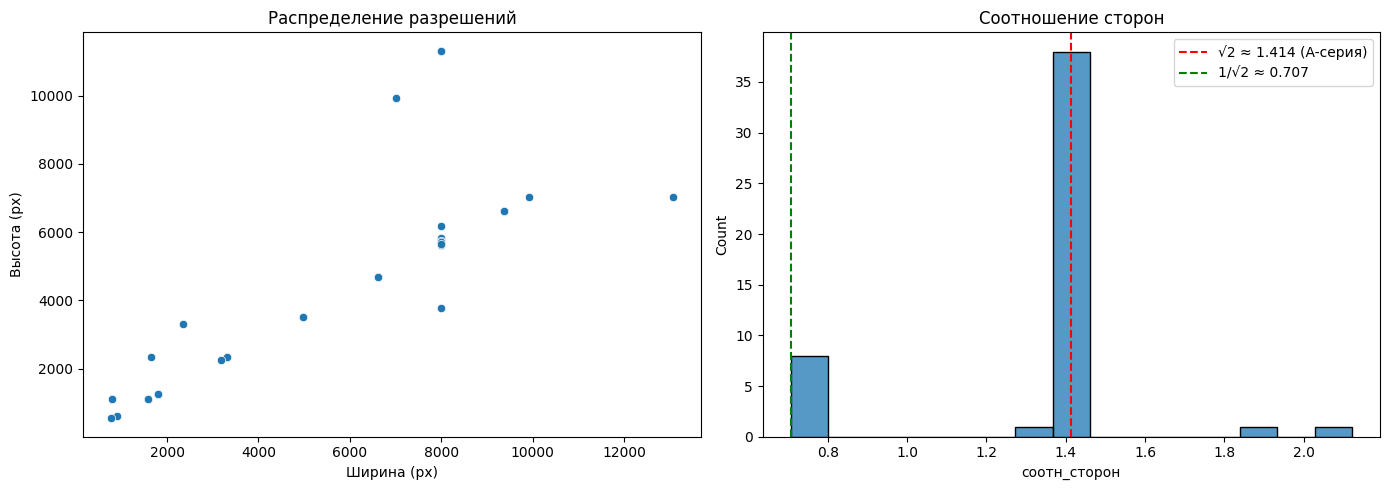

In [3]:
# Добавляем соотношение сторон
df_ppi['соотн_сторон'] = df_ppi['ширина'] / df_ppi['высота']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Диаграмма рассеяния разрешений
sns.scatterplot(data=df_ppi, x='ширина', y='высота', ax=axes[0])
axes[0].set_title("Распределение разрешений")
axes[0].set_xlabel("Ширина (px)")
axes[0].set_ylabel("Высота (px)")

# Гистограмма соотношения сторон
sns.histplot(data=df_ppi, x='соотн_сторон', bins=15, ax=axes[1])
axes[1].axvline(x=1.414, color='r', linestyle='--', label='√2 ≈ 1.414 (A-серия)')
axes[1].axvline(x=0.707, color='g', linestyle='--', label='1/√2 ≈ 0.707')
axes[1].legend()
axes[1].set_title("Соотношение сторон")

plt.tight_layout()
plt.show()

## Размеры штампов

Анализ пиксельных размеров ограничивающих рамок из аннотаций.

Проанализировано штампов: 49
         ширина_px    высота_px  соотн_сторон
count    49.000000    49.000000     49.000000
mean   1725.555427   475.397869      3.545891
std    1286.363236   312.823199      0.414028
min     344.519187   102.240406      3.150685
25%     728.365402   218.785553      3.311189
50%    1449.632014   356.393905      3.338983
75%    2189.074492   660.675598      3.610757
max    5651.937436  1254.306971      4.582822


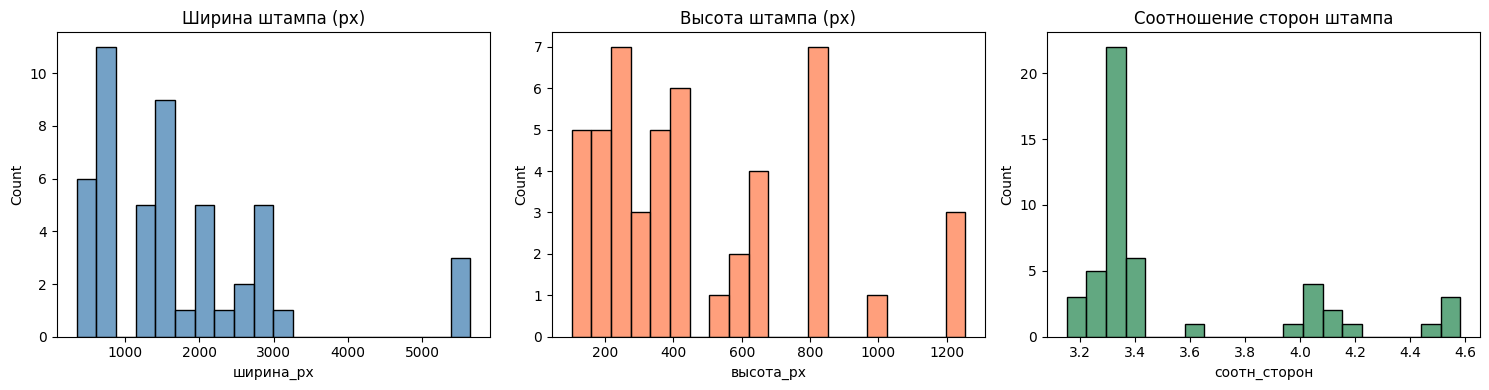

In [4]:
# Собираем данные о размерах штампов
stamp_data = []
for img_path in image_paths:
    img, labels = load_image_and_labels(img_path, LABEL_DIR)
    h, w = img.shape[:2]
    for label in labels:
        _, _, _, bw, bh = label
        stamp_data.append({
            'изображение': img_path.name,
            'ширина_px': bw * w,
            'высота_px': bh * h,
            'соотн_сторон': (bw * w) / (bh * h)
        })

df_stamp = pd.DataFrame(stamp_data)
print(f"Проанализировано штампов: {len(df_stamp)}")
print(df_stamp.describe())

# Визуализация распределения размеров
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.histplot(data=df_stamp, x='ширина_px', bins=20, ax=axes[0], color='steelblue')
axes[0].set_title("Ширина штампа (px)")
sns.histplot(data=df_stamp, x='высота_px', bins=20, ax=axes[1], color='coral')
axes[1].set_title("Высота штампа (px)")
sns.histplot(data=df_stamp, x='соотн_сторон', bins=20, ax=axes[2], color='seagreen')
axes[2].set_title("Соотношение сторон штампа")
plt.tight_layout()
plt.show()

## Выводы

**Изображения:**
- 49 изображений: 41 альбомных, 8 портретных
- Широкий диапазон разрешений: от 777x549 до 13063x11314 px

**PPI:**
- По метаданным: 23 изображения
- По ISO 216: 4 изображения
- Не определён: 22 изображения

**Штампы:**
- Физический размер: ~160x44 мм (в среднем)
- Пиксельный размер сильно варьируется из-за разного PPI
- При синтезе масштабируются под PPI фона

**Следующие шаги:**
- Реализовать CV baseline
- Запустить обучение YOLO
